## Lab-6: Power-Law Transformation
Write a Python program to perform the following tasks:</br>
    a) Read a grayscale image.</br>
    b) Apply power-law transformation using the formula: s=c* r</br>
    c) Use at least two different values of y and compare the results.</br>
    d) Display the original image and the transformed images with appropriate titles.</br>

In [5]:
import PIL.Image as image
import matplotlib.pyplot as plt
import numpy as np

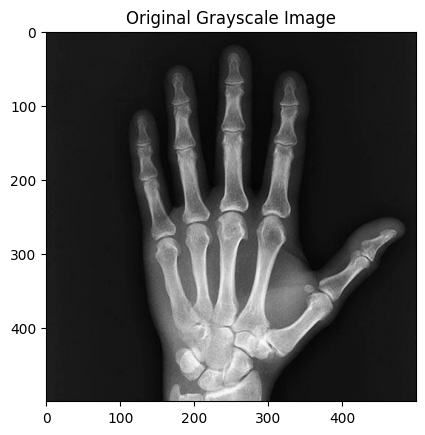

In [6]:
# 1. Read a grayscale image
gray_img = image.open("images/hand_xray.jpg").convert("L")

# Display original grayscale image
plt.imshow(gray_img, cmap='gray')
plt.title("Original Grayscale Image")

plt.show()

In [7]:
# 2. Convert image to numpy array
img = np.array(gray_img).astype('float32')

# Normalize pixel values to range [0,1]
img_norm = img / 255.0

# Power-law formula: s = c * r^gamma
c = 1   # constant

In [8]:
# 3. Apply two different gamma values
gamma1 = 0.5   # Brightens the image
gamma2 = 2.0   # Darkens the image

power_img1 = c * (img_norm ** gamma1)
power_img2 = c * (img_norm ** gamma2)

# Convert back to range [0,255]
power_img1 = np.clip(power_img1 * 255, 0, 255).astype('uint8')
power_img2 = np.clip(power_img2 * 255, 0, 255).astype('uint8')


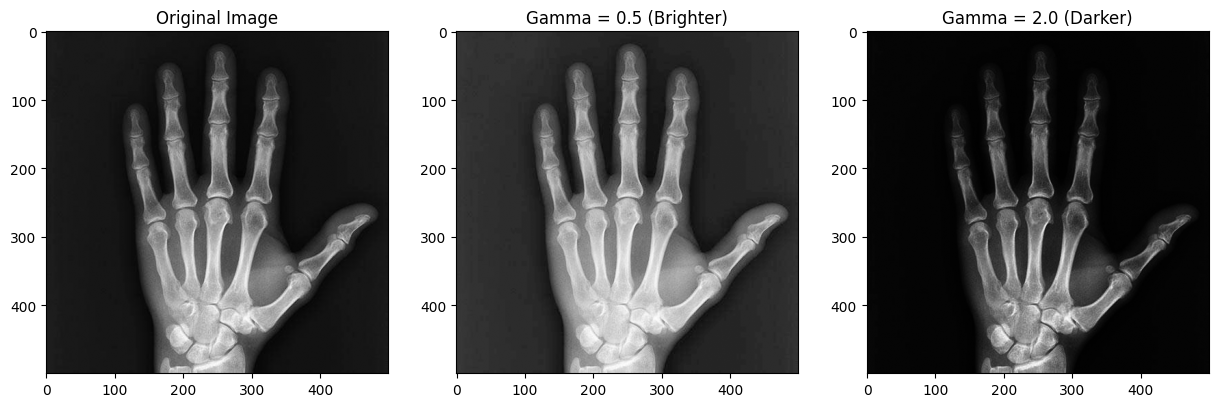

In [9]:
# 4. Display original and transformed images
plt.figure(figsize=(15, 8))

plt.subplot(1, 3, 1)
plt.imshow(gray_img, cmap='gray')
plt.title("Original Image")

plt.subplot(1, 3, 2)
plt.imshow(power_img1, cmap='gray')
plt.title("Gamma = 0.5 (Brighter)")

plt.subplot(1, 3, 3)
plt.imshow(power_img2, cmap='gray')
plt.title("Gamma = 2.0 (Darker)")

plt.show()


## 1️⃣ Convert Image to NumPy Array

```python img = np.array(gray_img).astype('float32') ```

### Why convert to NumPy array?

- A grayscale image loaded using **PIL** is an image object.
- Mathematical operations (like power, multiplication, division) are easier and faster using NumPy arrays.
- NumPy allows pixel-wise operations on the entire image at once.

### Why `astype('float32')`?

- Original grayscale pixel values are stored as `uint8` (unsigned 8-bit integer).
- `uint8` range is **0 to **255**** and does **NOT** support decimal values.
- Power-law transformation involves exponentiation and division, which produce decimal numbers.
- So we convert to `float32` to safely perform mathematical calculations.

---

## 2️⃣ Normalize Pixel Values

```python img_norm = img / **255**.0 ```

### Why normalize?

- Original pixel values range from **0 to **255****.
- Power-law formula works better when values are in the range **0 to 1**.
- Dividing by **255** converts:

    * 0 → 0.0
    * **255** → 1.0

This ensures proper gamma correction behavior.

---

## 3️⃣ Power-Law Formula

```python s = c * r^gamma ```

Where:

- `r` = input pixel value
- `s` = output pixel value
- `c` = constant
- `gamma` = exponent value

---

## 4️⃣ Why Use Constant `c`?

```python c = 1 ```

- `c` is a scaling constant.
- It controls overall brightness intensity.
- In most gamma correction cases, `c = 1` is sufficient.
- If needed, increasing `c` makes image brighter overall.

---

## 5️⃣ Why Use Gamma?

```python gamma1 = 0.5 gamma2 = 2.0 ```

Gamma controls brightness behavior:

- **gamma < 1**

    * Expands dark pixels
    * Makes image brighter

- **gamma > 1**

    * Compresses bright pixels
    * Makes image darker

So:

- `gamma = 0.5` → Bright image
- `gamma = 2.0` → Dark image

---

## 6️⃣ Apply Power Operation

```python power_img1 = c * (img_norm ** gamma1) power_img2 = c * (img_norm ** gamma2) ```

- `**` means exponentiation.
- Each pixel is raised to the power of gamma.
- Operation is applied to all pixels at once (vectorized operation).

---

## 7️⃣ Convert Back to 0–255 Range

```python power_img1 = power_img1 * **255** ```

Why multiply by **255**?

- After normalization, pixel range was 0–1.
- To display/save image, we must convert back to 0–**255**.

---

## 8️⃣ Why Use `np.clip()`?

```python np.clip(power_img1, 0, **255**) ```

- Some pixel values may go below 0 or above **255**.
- Valid grayscale range is strictly **0 to **255****.
- `clip()` ensures:

    * Values < 0 → become 0
    * Values > **255** → become **255**

This prevents image distortion or errors.

---

## 9️⃣ Why Convert Back to `uint8`?

```python .astype('uint8') ```

- Image display functions expect pixel type as `uint8`.
- `uint8` means:

    * Unsigned integer
    * 8-bit storage
    * Range: 0–**255**

Without converting:

- Image may not display correctly
- May appear completely white or black
- Or produce errors

---

# 🔎 How This Portion Works (Step-by-Step Flow)

- Convert image to NumPy array for mathematical operations.
- Convert data type to float for safe calculations. 
- Normalize pixel values to range 0–1. 
- Apply power-law formula using gamma. 
- Convert result back to 0–255 scale. 
- Clip values to valid grayscale range. 
- Convert back to `uint8` for proper image display.

---

# 🎯 Summary

| Step             | Purpose                        |
| ---------------- | ------------------------------ |
| Convert to NumPy | Enable mathematical operations |
| float32          | Allow decimal calculations     |
| Normalize (÷255) | Required for gamma correction  |
| `c`              | Controls scaling intensity     |
| `gamma`          | Controls brightness/darkness   |
| Multiply by 255  | Return to image range          |
| `clip()`         | Keep valid pixel range         |
| `uint8`          | Required for image display     |

---

✅ This process ensures correct and controlled brightness transformation using the Power-Law (Gamma) method.
